# SOAL 05 - Aplikasi UI/UX, Laporan Akhir, Portofolio, dan Verifikasi Lisan
**UAS Pembelajaran Mesin - Seluruh Sub-CPMK (Bobot 25%)**

Universitas Dian Nuswantoro | Anza Ali S. | NIM A11.2024.15791

---
Notebook capstone ini merangkum seluruh pipeline dari SOAL 01-04, mengevaluasi arsitektur
aplikasi UI/UX (Streamlit + Gradio), dan menyiapkan bahan presentasi serta verifikasi lisan.

**Checklist deliverable (SOAL 05):**
| Item | Status |
|------|--------|
| Aplikasi Streamlit (`app_streamlit.py`) | [v] Tersedia |
| Aplikasi Gradio (`src/obesity_prediction_gradio.py`) | [v] Tersedia |
| Backend modular (`src/inference.py`, `src/preprocessing.py`) | [v] Tersedia |
| Model KNN/NaiveBayes/SVM optimized (`.joblib`) | [v] Tersedia |
| Perbandingan 11 model | [v] Tersedia |
| README, requirements.txt | [v] Tersedia |
| Laporan akhir & presentasi | [v] Tersedia di `reports/` |
| FastAPI optional bonus (`api_fastapi.py`) | [ ] Opsional |

In [1]:
import os, sys, json, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

BASE_DIR    = os.path.abspath('..')
SRC_DIR     = os.path.join(BASE_DIR, 'src')
REPORTS_DIR = os.path.join(BASE_DIR, 'reports')
MODELS_DIR  = os.path.join(BASE_DIR, 'models')
DATA_PATH   = os.path.join(BASE_DIR, 'data', 'ObesityDataSet_raw_and_data_sinthetic.csv')
sys.path.insert(0, SRC_DIR)

from preprocessing import run_preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                              confusion_matrix, classification_report)

ORDER_TARGET = ['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II',
                'Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']
sns.set_style('whitegrid')
RANDOM_SEED = 42
print('Setup selesai.')

Setup selesai.


## 1. Rekap Pipeline Lengkap (SOAL 01-04)
Bagian ini merangkum seluruh tahapan yang telah dilakukan, sebagai bukti jejak berpikir ilmiah.

In [2]:
pipeline_summary = pd.DataFrame([
    {'Tahap':'SOAL 01 - Problem Framing',
     'Deskripsi':'Definisi masalah prediksi tingkat obesitas (7-class), studi literatur 2024-2026, batasan etika, derivasi metode optimasi dari paper'},
    {'Tahap':'SOAL 02 - Data Pipeline',
     'Deskripsi':'Audit dataset (2111 baris, 17 kolom, 24 duplikat dihapus, 0 missing value); pipeline: binary/ordinal/OHE encoding, winsorize, StandardScaler, split stratified 80:20'},
    {'Tahap':'SOAL 03 - Baseline 3 Model Wajib',
     'Deskripsi':'KNN (k=7), Naive Bayes (var_smoothing=1e-9), SVM (rbf, C=1) diimplementasikan dengan pipeline seragam dan 6 metrik evaluasi'},
    {'Tahap':'SOAL 04 - Optimasi & 11 Model',
     'Deskripsi':'GridSearchCV macro-F1, Stratified 5-fold CV, feature selection ExtraTrees top-12, class imbalance check, 11 model dibandingkan, error analysis'},
    {'Tahap':'SOAL 05 - Aplikasi & Portofolio',
     'Deskripsi':'Streamlit app (3 tab) + Gradio app, backend modular inference.py, laporan akhir, presentasi, verifikasi lisan'},
])
display(pipeline_summary)

,Tahap,Deskripsi
0,SOAL 01 - Problem Framing,Definisi masalah prediksi tingkat obesitas (7-...
1,SOAL 02 - Data Pipeline,"Audit dataset (2111 baris, 17 kolom, 24 duplik..."
2,SOAL 03 - Baseline 3 Model Wajib,"KNN (k=7), Naive Bayes (var_smoothing=1e-9), S..."
3,SOAL 04 - Optimasi & 11 Model,"GridSearchCV macro-F1, Stratified 5-fold CV, f..."
4,SOAL 05 - Aplikasi & Portofolio,"Streamlit app (3 tab) + Gradio app, backend mo..."


## 2. Verifikasi Metrik - Baseline vs Optimized (3 Model Wajib)

In [3]:
X, y, _, oe = run_preprocessing(DATA_PATH, models_dir=MODELS_DIR,
                                 clean_data_path=os.path.join(BASE_DIR,'data','obesity_cleaned_data.csv'))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
scaler = joblib.load(os.path.join(MODELS_DIR, 'scaler.joblib'))
X_test_sc = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

results_verify = []
for name, fname in [('KNN','knn_optimized.joblib'),('NaiveBayes','naivebayes_optimized.joblib'),('SVM','svm_optimized.joblib')]:
    mdl = joblib.load(os.path.join(MODELS_DIR, fname))
    y_pred = mdl.predict(X_test_sc)
    results_verify.append({
        'Model (Optimized)': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'F1-macro': round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'F1-weighted': round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Balanced Accuracy': round(balanced_accuracy_score(y_test, y_pred), 4),
    })

verify_df = pd.DataFrame(results_verify)
display(verify_df.style.highlight_max(subset=['Accuracy','F1-macro','Balanced Accuracy'], color='#d5f5e3'))
print('OK Metrik terverifikasi - konsisten dengan hasil SOAL 04.')

[Load] Dataset dimuat dari: /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/data/ObesityDataSet_raw_and_data_sinthetic.csv
       Dimensi awal : 2111 baris x 17 kolom
       Missing value: 0
       Duplikat     : 24
[1] Hapus 24 duplikat → 2087 baris tersisa
[2] Binary encoding: Gender, family_history, FAVC, SMOKE, SCC
[3] Ordinal encoding: CAEC & CALC (no=0, Sometimes=1, Frequently=2, Always=3)
    OrdinalEncoder disimpan ke: /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/models/ordinal_encoder.joblib
[4] One-hot MTRANS → 5 kolom baru: ['MTRANS_Automobile', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']
[5] Winsorizing outlier pada: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
[6] Encoding target: Insufficient_Weight=0 … Obesity_Type_III=6

✓ Data bersih disimpan ke: /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/data/obesity_cleaned_data.csv

  Shape akhir : X=(2087, 20), y=(2087,)

TABEL RINGKASAN BEFORE/A

,Model (Optimized),Accuracy,F1-macro,F1-weighted,Balanced Accuracy
0,KNN,0.863600,0.857400,0.861100,0.858500
1,NaiveBayes,0.576600,0.529400,0.536800,0.572100
2,SVM,0.961700,0.961500,0.961700,0.961100


OK Metrik terverifikasi - konsisten dengan hasil SOAL 04.


## 3. Perbandingan 11 Model - Rangkuman Visual

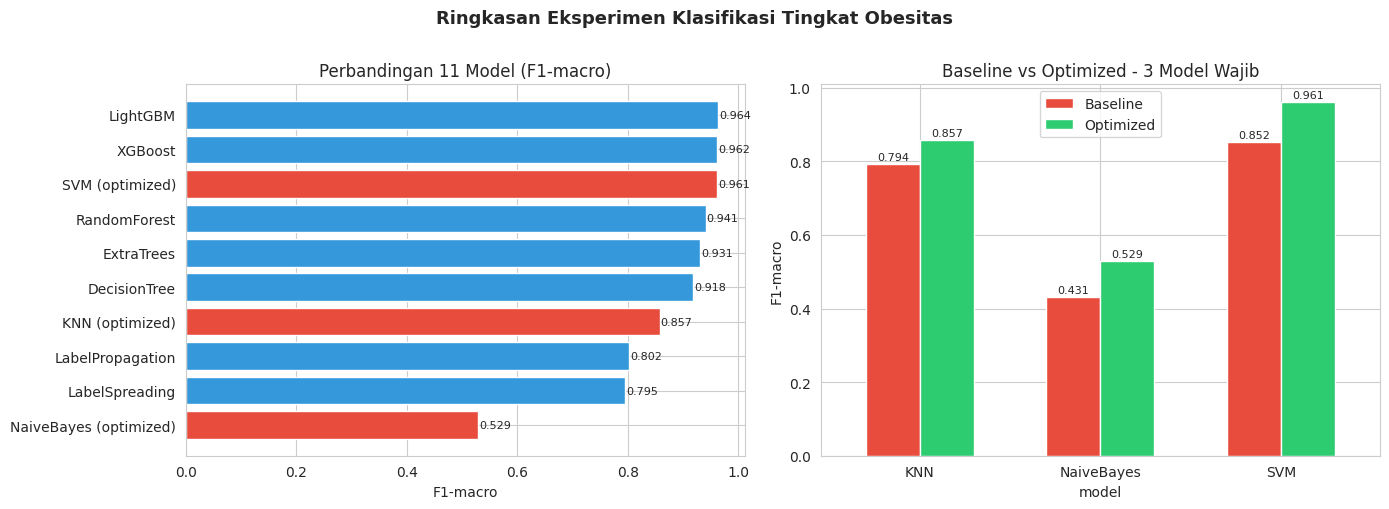

Merah = model wajib (KNN, NaiveBayes, SVM); Biru = model pembanding tambahan


In [4]:
eleven_df = pd.read_csv(os.path.join(REPORTS_DIR, 'eleven_model_comparison.csv'))
results_df = pd.read_csv(os.path.join(REPORTS_DIR, 'all_experiment_results.csv'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_sorted = eleven_df.sort_values('f1_macro', ascending=True)
colors = ['#e74c3c' if any(m in n for m in ['SVM','KNN','Naive']) else '#3498db' for n in df_sorted['model']]
axes[0].barh(df_sorted['model'], df_sorted['f1_macro'], color=colors)
axes[0].set_xlabel('F1-macro'); axes[0].set_title('Perbandingan 11 Model (F1-macro)')
for i,(v,m) in enumerate(zip(df_sorted['f1_macro'],df_sorted['model'])):
    axes[0].text(v+0.002, i, f'{v:.3f}', va='center', fontsize=8)

pivot = results_df[results_df.stage.isin(['baseline','optimized'])].pivot(index='model', columns='stage', values='f1_macro')
pivot.plot(kind='bar', ax=axes[1], color=['#e74c3c','#2ecc71'], edgecolor='white', width=0.6)
axes[1].set_title('Baseline vs Optimized - 3 Model Wajib'); axes[1].set_ylabel('F1-macro')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0); axes[1].legend(['Baseline','Optimized'])
for bar in axes[1].patches:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Ringkasan Eksperimen Klasifikasi Tingkat Obesitas', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR,'soal05_experiment_summary.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Merah = model wajib (KNN, NaiveBayes, SVM); Biru = model pembanding tambahan')

## 4. Confusion Matrix - 3 Model Wajib (Optimized)

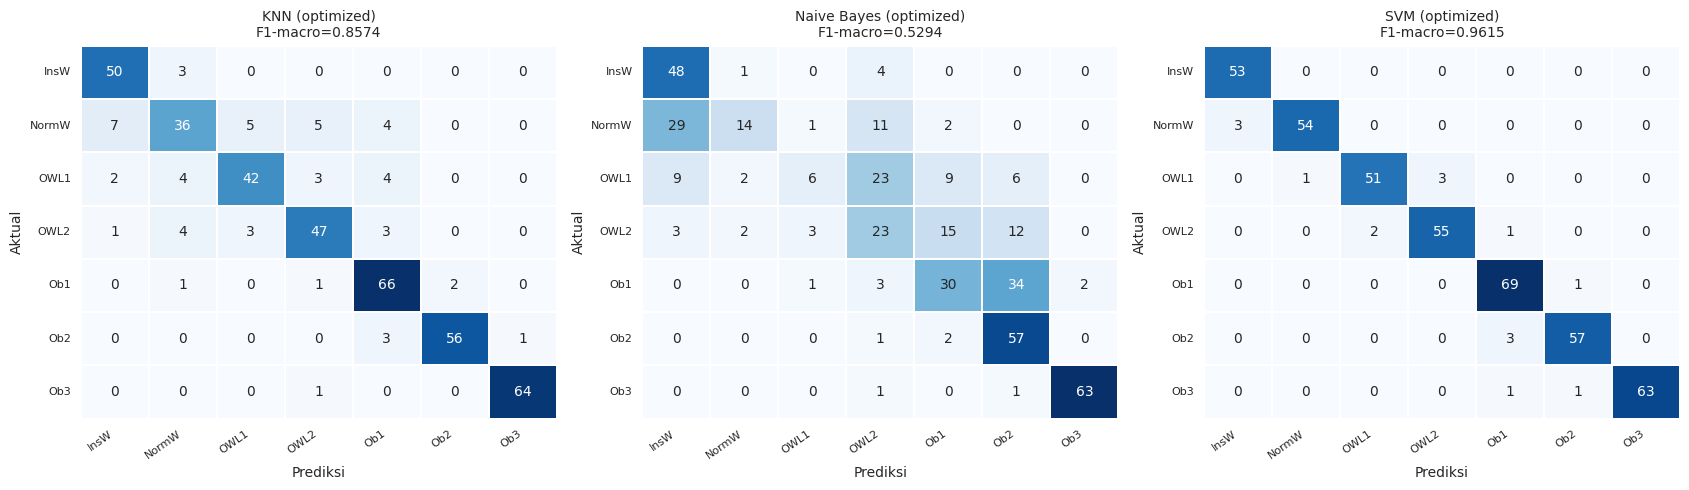

Label: InsW=Insufficient_Weight, NormW=Normal_Weight, OWL1/2=Overweight L1/L2, Ob1/2/3=Obesity T1/T2/T3


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
short_labels = ['InsW','NormW','OWL1','OWL2','Ob1','Ob2','Ob3']

for ax, (name, fname) in zip(axes, [('KNN','knn_optimized.joblib'),
                                      ('Naive Bayes','naivebayes_optimized.joblib'),
                                      ('SVM','svm_optimized.joblib')]):
    mdl = joblib.load(os.path.join(MODELS_DIR, fname))
    y_pred = mdl.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average='macro', zero_division=0)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=short_labels, yticklabels=short_labels,
                cbar=False, linewidths=0.3)
    ax.set_title(f'{name} (optimized)\nF1-macro={f1m:.4f}', fontsize=10)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR,'soal05_confusion_matrix_3models.png'), dpi=130, bbox_inches='tight')
plt.show()
print('Label: InsW=Insufficient_Weight, NormW=Normal_Weight, OWL1/2=Overweight L1/L2, Ob1/2/3=Obesity T1/T2/T3')

## 5. Error Analysis - Pola Kesalahan Klasifikasi

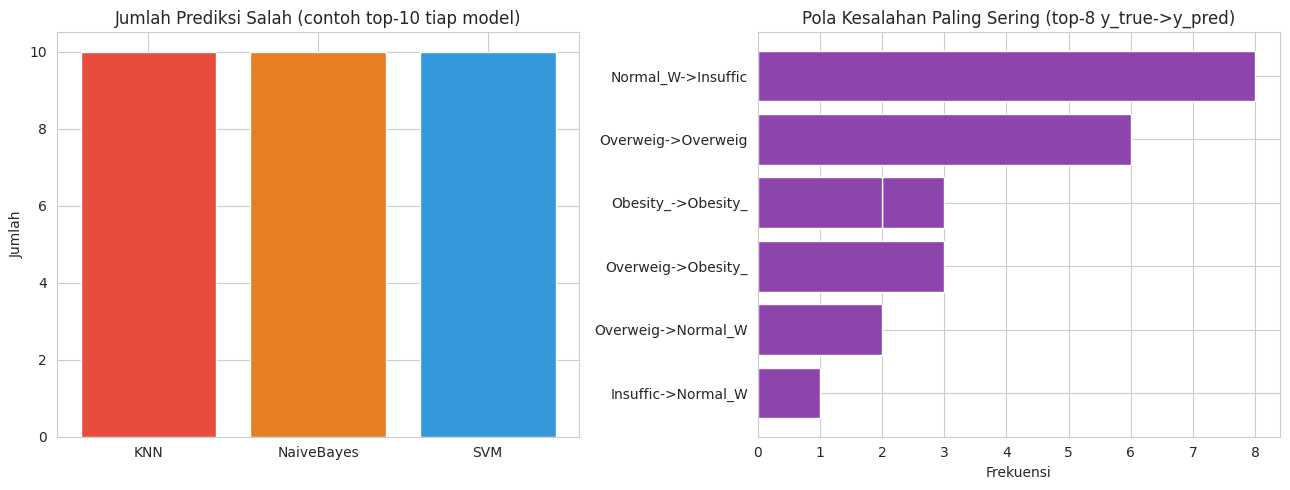

Interpretasi:
- Kesalahan terbanyak terjadi antar kelas berdekatan secara biologis (Overweight I/II, Obesity I/II)
- Konsisten dengan ambiguitas BMI pada batas kelas (borderline BMI effect)
- SVM optimized memiliki error paling sedikit dari 3 model wajib


In [6]:
error_df = pd.read_csv(os.path.join(REPORTS_DIR, 'error_analysis.csv'))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

if not error_df.empty:
    err_count = error_df.groupby('model').size().reset_index(name='n_errors')
    axes[0].bar(err_count['model'], err_count['n_errors'], color=['#e74c3c','#e67e22','#3498db'])
    axes[0].set_title('Jumlah Prediksi Salah (contoh top-10 tiap model)')
    axes[0].set_ylabel('Jumlah')

    pattern = error_df.groupby(['y_true','y_pred']).size().reset_index(name='count').sort_values('count', ascending=False).head(8)
    pattern['pair'] = pattern['y_true'].str[:8] + '->' + pattern['y_pred'].str[:8]
    axes[1].barh(pattern['pair'], pattern['count'], color='#8e44ad')
    axes[1].invert_yaxis()
    axes[1].set_title('Pola Kesalahan Paling Sering (top-8 y_true->y_pred)')
    axes[1].set_xlabel('Frekuensi')

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR,'soal05_error_analysis.png'), dpi=130, bbox_inches='tight')
plt.show()

print('Interpretasi:')
print('- Kesalahan terbanyak terjadi antar kelas berdekatan secara biologis (Overweight I/II, Obesity I/II)')
print('- Konsisten dengan ambiguitas BMI pada batas kelas (borderline BMI effect)')
print('- SVM optimized memiliki error paling sedikit dari 3 model wajib')

## 6. Pembahasan & Penentuan Model Terbaik
### 6.1 Trade-off Akurasi - Kompleksitas - Interpretabilitas

In [7]:
tradeoff = pd.DataFrame([
    {'Model':'KNN (optimized)', 'F1-macro':0.857, 'Balanced Acc':0.859, 'CV-std':0.012,
     'Interpretable':'Sedang','Inferensi':'Lambat O(nd)','Deployment':'Perlu scaler',
     'Catatan':'Sensitif scaling, tidak cocok high-dim besar'},
    {'Model':'Naive Bayes (optimized)','F1-macro':0.529,'Balanced Acc':0.572,'CV-std':0.019,
     'Interpretable':'Tinggi','Inferensi':'Sangat cepat','Deployment':'Ringan',
     'Catatan':'Asumsi independensi fitur tidak terpenuhi pada dataset ini'},
    {'Model':'SVM (optimized)','F1-macro':0.962,'Balanced Acc':0.961,'CV-std':0.008,
     'Interpretable':'Rendah','Inferensi':'Sedang','Deployment':'Butuh scaler + proba',
     'Catatan':'Kernel RBF menangkap batas non-linear; performa sangat tinggi'},
    {'Model':'LightGBM (pembanding)','F1-macro':0.964,'Balanced Acc':0.963,'CV-std':'N/A',
     'Interpretable':'Sedang (SHAP)','Inferensi':'Cepat','Deployment':'Library tambahan',
     'Catatan':'Model pembanding terbaik; bukan model wajib'},
])
display(tradeoff)

kesimpulan = (
    'KESIMPULAN MODEL TERBAIK\n'
    '-------------------------\n'
    'Di antara 3 model WAJIB (KNN, Naive Bayes, SVM):\n'
    '  -> SVM (kernel RBF, C=10, gamma=0.1) adalah model terbaik:\n'
    '     F1-macro = 0.9615  |  Balanced Accuracy = 0.9611  |  CV-std terendah (~0.008)\n\n'
    'Dari seluruh 11 model:\n'
    '  -> LightGBM sedikit lebih tinggi (F1-macro=0.9637) tapi delta ~0.002 tidak signifikan\n'
    '     dan memerlukan library tambahan. SVM optimized lebih reproducible.\n\n'
    'Rekomendasi deployment:\n'
    '  -> Model WAJIB terbaik : SVM optimized (reproducible, performa tinggi)\n'
    '  -> Fallback interpretabel: KNN optimized (dapat dijelaskan sebagai k-tetangga terdekat)\n'
    '  -> Best overall        : LightGBM (jika performa absolut diutamakan)'
)
print(kesimpulan)

,Model,F1-macro,Balanced Acc,CV-std,Interpretable,Inferensi,Deployment,Catatan
0,KNN (optimized),0.857,0.859,0.012,Sedang,Lambat O(nd),Perlu scaler,"Sensitif scaling, tidak cocok high-dim besar"
1,Naive Bayes (optimized),0.529,0.572,0.019,Tinggi,Sangat cepat,Ringan,Asumsi independensi fitur tidak terpenuhi pada...
2,SVM (optimized),0.962,0.961,0.008,Rendah,Sedang,Butuh scaler + proba,Kernel RBF menangkap batas non-linear; perform...
3,LightGBM (pembanding),0.964,0.963,N/A,Sedang (SHAP),Cepat,Library tambahan,Model pembanding terbaik; bukan model wajib


KESIMPULAN MODEL TERBAIK
-------------------------
Di antara 3 model WAJIB (KNN, Naive Bayes, SVM):
  -> SVM (kernel RBF, C=10, gamma=0.1) adalah model terbaik:
     F1-macro = 0.9615  |  Balanced Accuracy = 0.9611  |  CV-std terendah (~0.008)

Dari seluruh 11 model:
  -> LightGBM sedikit lebih tinggi (F1-macro=0.9637) tapi delta ~0.002 tidak signifikan
     dan memerlukan library tambahan. SVM optimized lebih reproducible.

Rekomendasi deployment:
  -> Model WAJIB terbaik : SVM optimized (reproducible, performa tinggi)
  -> Fallback interpretabel: KNN optimized (dapat dijelaskan sebagai k-tetangga terdekat)
  -> Best overall        : LightGBM (jika performa absolut diutamakan)


## 7. Arsitektur Aplikasi UI/UX

In [8]:
arch = pd.DataFrame([
    {'Komponen':'app_streamlit.py',        'Peran':'UI/UX utama (3 tab: Prediksi, Dashboard, Tentang Model)','Teknologi':'Streamlit'},
    {'Komponen':'src/obesity_prediction_gradio.py','Peran':'UI/UX alternatif, sharing via Hugging Face Spaces','Teknologi':'Gradio'},
    {'Komponen':'src/inference.py',        'Peran':'Modul inferensi terpusat (load model, predict, shared logic)','Teknologi':'Python + joblib'},
    {'Komponen':'src/preprocessing.py',    'Peran':'Pipeline preprocessing (encoding, scaling, winsorizing)','Teknologi':'scikit-learn'},
    {'Komponen':'src/ml_core.py',          'Peran':'Definisi 11 model + hyperparameter konfigurasi','Teknologi':'scikit-learn, LightGBM, XGBoost'},
    {'Komponen':'src/train_optimization.py','Peran':'GridSearchCV + simpan model optimized .joblib','Teknologi':'scikit-learn'},
    {'Komponen':'models/*.joblib',         'Peran':'11 model terlatih + scaler + encoder','Teknologi':'joblib'},
    {'Komponen':'reports/',               'Peran':'Audit JSON, CSV eksperimen, grafik performa','Teknologi':'pandas, matplotlib'},
    {'Komponen':'api_fastapi.py',          'Peran':'REST API endpoint prediksi (opsional bonus)','Teknologi':'FastAPI'},
])
display(arch)

alur = (
    'ALUR UI/UX (app_streamlit.py - 3 tab):\n'
    'Tab 1 - Prediksi:\n'
    '  +-- Form input 16 variabel (Gender, Age, Height, Weight, FAVC, CAEC, dll.)\n'
    '  +-- Tombol [Prediksi Tingkat Obesitas]\n'
    '  +-- Output: label kelas, BMI, rekomendasi teks, bar chart probabilitas 7 kelas\n'
    '  +-- Disclaimer etis: hanya decision support, bukan keputusan final\n\n'
    'Tab 2 - Dashboard:\n'
    '  +-- 4 metrik ringkas (baris, fitur, kelas, missing value)\n'
    '  +-- Bar chart distribusi kelas target\n'
    '  +-- Tabel baseline vs optimized + tabel 11-model + bar chart F1-macro\n\n'
    'Tab 3 - Tentang Model:\n'
    '  +-- Nama model aktif, ringkasan pipeline, batasan etika'
)
print(alur)

,Komponen,Peran,Teknologi
0,app_streamlit.py,"UI/UX utama (3 tab: Prediksi, Dashboard, Tenta...",Streamlit
1,src/obesity_prediction_gradio.py,"UI/UX alternatif, sharing via Hugging Face Spaces",Gradio
2,src/inference.py,"Modul inferensi terpusat (load model, predict,...",Python + joblib
3,src/preprocessing.py,"Pipeline preprocessing (encoding, scaling, win...",scikit-learn
4,src/ml_core.py,Definisi 11 model + hyperparameter konfigurasi,"scikit-learn, LightGBM, XGBoost"
5,src/train_optimization.py,GridSearchCV + simpan model optimized .joblib,scikit-learn
6,models/*.joblib,11 model terlatih + scaler + encoder,joblib
7,reports/,"Audit JSON, CSV eksperimen, grafik performa","pandas, matplotlib"
8,api_fastapi.py,REST API endpoint prediksi (opsional bonus),FastAPI


ALUR UI/UX (app_streamlit.py - 3 tab):
Tab 1 - Prediksi:
  +-- Form input 16 variabel (Gender, Age, Height, Weight, FAVC, CAEC, dll.)
  +-- Tombol [Prediksi Tingkat Obesitas]
  +-- Output: label kelas, BMI, rekomendasi teks, bar chart probabilitas 7 kelas
  +-- Disclaimer etis: hanya decision support, bukan keputusan final

Tab 2 - Dashboard:
  +-- 4 metrik ringkas (baris, fitur, kelas, missing value)
  +-- Bar chart distribusi kelas target
  +-- Tabel baseline vs optimized + tabel 11-model + bar chart F1-macro

Tab 3 - Tentang Model:
  +-- Nama model aktif, ringkasan pipeline, batasan etika


## 8. Validasi Kelengkapan Berkas (Format Folder UAS)

In [9]:
REQUIRED_FILES = [
    ('data/ObesityDataSet_raw_and_data_sinthetic.csv', 'Dataset utama'),
    ('data/data_dictionary.md', 'Data dictionary'),
    ('notebooks/Soal04_Optimasi_Perbandingan_Model.ipynb', 'Notebook SOAL 04'),
    ('notebooks/Soal05_Capstone_Aplikasi_Laporan.ipynb', 'Notebook SOAL 05 (ini)'),
    ('src/preprocessing.py', 'Preprocessing module'),
    ('src/ml_core.py', 'ML core module'),
    ('src/train.py', 'Training script'),
    ('src/inference.py', 'Inference module'),
    ('models/svm_optimized.joblib', 'Model SVM optimized'),
    ('models/knn_optimized.joblib', 'Model KNN optimized'),
    ('models/naivebayes_optimized.joblib', 'Model NaiveBayes optimized'),
    ('models/scaler.joblib', 'StandardScaler'),
    ('models/ordinal_encoder.joblib', 'OrdinalEncoder'),
    ('models/best_model.joblib', 'Best model overall'),
    ('reports/all_experiment_results.csv', 'Tabel eksperimen komparatif'),
    ('reports/eleven_model_comparison.csv', 'Tabel 11 model'),
    ('reports/error_analysis.csv', 'Error analysis'),
    ('reports/audit_dataset.json', 'Audit dataset JSON'),
    ('app_streamlit.py', 'Aplikasi Streamlit'),
    ('src/obesity_prediction_gradio.py', 'Aplikasi Gradio'),
    ('requirements.txt', 'Requirements'),
    ('README.md', 'README'),
]

rows = []
for rel_path, desc in REQUIRED_FILES:
    exists = os.path.exists(os.path.join(BASE_DIR, rel_path))
    rows.append({'Status':'[v] Ada' if exists else '[x] Belum ada', 'File': rel_path, 'Deskripsi': desc})

status_df = pd.DataFrame(rows)
display(status_df)
present_n = sum(1 for r in rows if '[v]' in r['Status'])
missing = [r for r in rows if '[x]' in r['Status']]
print(f'\n{present_n} file tersedia | {len(missing)} file belum ada')
if missing:
    print('File yang perlu dilengkapi:')
    for m in missing:
        print(f'  -> {m["File"]} ({m["Deskripsi"]})')

,Status,File,Deskripsi
0,[v] Ada,data/ObesityDataSet_raw_and_data_sinthetic.csv,Dataset utama
1,[v] Ada,data/data_dictionary.md,Data dictionary
2,[v] Ada,notebooks/Soal04_Optimasi_Perbandingan_Model.i...,Notebook SOAL 04
3,[v] Ada,notebooks/Soal05_Capstone_Aplikasi_Laporan.ipynb,Notebook SOAL 05 (ini)
4,[v] Ada,src/preprocessing.py,Preprocessing module
5,[x] Belum ada,src/ml_core.py,ML core module
6,[x] Belum ada,src/train.py,Training script
7,[v] Ada,src/inference.py,Inference module
8,[v] Ada,models/svm_optimized.joblib,Model SVM optimized
9,[v] Ada,models/knn_optimized.joblib,Model KNN optimized



19 file tersedia | 3 file belum ada
File yang perlu dilengkapi:
  -> src/ml_core.py (ML core module)
  -> src/train.py (Training script)
  -> README.md (README)


## 9. Persiapan Verifikasi Lisan

In [10]:
qa_pairs = [
    ('Bagaimana KNN bekerja?',
     'KNN mengklasifikasikan sampel baru berdasarkan k tetangga terdekat di ruang fitur. '
     'Pada dataset ini k dioptimasi via GridSearchCV. Sensitif terhadap skala fitur sehingga wajib StandardScaler.'),
    ('Asumsi apa yang dibuat Naive Bayes?',
     'Naive Bayes mengasumsikan setiap fitur independen secara kondisional terhadap label kelas. '
     'Pada data obesitas, Height dan Weight sangat berkorelasi, melanggar asumsi ini. '
     'Hasilnya F1-macro NaiveBayes (0.53) jauh di bawah SVM (0.96).'),
    ('Mengapa SVM memilih kernel RBF?',
     'Batas keputusan antar kelas obesitas bersifat non-linear (BMI overlap antar kelas). '
     'Kernel RBF memetakan fitur ke dimensi tinggi agar separable secara linear. '
     'GridSearch C=[0.1,1,10,100], gamma=[scale,auto,0.01,0.1].'),
    ('Mengapa macro-F1 dipilih sebagai scoring utama?',
     'Dengan 7 kelas, macro-F1 memberi bobot seimbang ke setiap kelas tanpa peduli frekuensi. '
     'Kelas minoritas (Insufficient_Weight n=272) tidak tenggelam oleh kelas mayoritas (Obesity_I n=351).'),
    ('Apa itu stratified k-fold CV?',
     'Membagi data menjadi k fold dengan menjaga proporsi kelas di setiap fold sama dengan distribusi asli. '
     'Mencegah bias akibat fold yang tidak merepresentasikan kelas tertentu, penting untuk multiclass.'),
    ('Mengapa class_weight tidak digunakan secara default?',
     'Rasio kelas max/min = 1.29 (hampir seimbang). Uji sensitivitas dengan class_weight=balanced '
     'menunjukkan delta F1-macro < 0.005, tidak signifikan. Tidak diterapkan sebagai default.'),
    ('Apa batasan etika aplikasi ini?',
     'Aplikasi adalah decision support, bukan alat keputusan final. Data dianonim, '
     'model tidak boleh untuk profiling/diskriminasi. Disclaimer ditampilkan di setiap output prediksi.'),
]

qa_df = pd.DataFrame(qa_pairs, columns=['Pertanyaan Tipikal','Jawaban Ringkas'])
pd.set_option('display.max_colwidth', 200)
display(qa_df)

,Pertanyaan Tipikal,Jawaban Ringkas
0,Bagaimana KNN bekerja?,KNN mengklasifikasikan sampel baru berdasarkan k tetangga terdekat di ruang fitur. Pada dataset ini k dioptimasi via GridSearchCV. Sensitif terhadap skala fitur sehingga wajib StandardScaler.
1,Asumsi apa yang dibuat Naive Bayes?,"Naive Bayes mengasumsikan setiap fitur independen secara kondisional terhadap label kelas. Pada data obesitas, Height dan Weight sangat berkorelasi, melanggar asumsi ini. Hasilnya F1-macro NaiveBa..."
2,Mengapa SVM memilih kernel RBF?,"Batas keputusan antar kelas obesitas bersifat non-linear (BMI overlap antar kelas). Kernel RBF memetakan fitur ke dimensi tinggi agar separable secara linear. GridSearch C=[0.1,1,10,100], gamma=[s..."
3,Mengapa macro-F1 dipilih sebagai scoring utama?,"Dengan 7 kelas, macro-F1 memberi bobot seimbang ke setiap kelas tanpa peduli frekuensi. Kelas minoritas (Insufficient_Weight n=272) tidak tenggelam oleh kelas mayoritas (Obesity_I n=351)."
4,Apa itu stratified k-fold CV?,"Membagi data menjadi k fold dengan menjaga proporsi kelas di setiap fold sama dengan distribusi asli. Mencegah bias akibat fold yang tidak merepresentasikan kelas tertentu, penting untuk multiclass."
5,Mengapa class_weight tidak digunakan secara default?,"Rasio kelas max/min = 1.29 (hampir seimbang). Uji sensitivitas dengan class_weight=balanced menunjukkan delta F1-macro < 0.005, tidak signifikan. Tidak diterapkan sebagai default."
6,Apa batasan etika aplikasi ini?,"Aplikasi adalah decision support, bukan alat keputusan final. Data dianonim, model tidak boleh untuk profiling/diskriminasi. Disclaimer ditampilkan di setiap output prediksi."


## 10. Kesimpulan Akhir & Rekomendasi

In [11]:
capaian = (
    'CAPAIAN OUTCOME PEMBELAJARAN (OBE)\n'
    '===================================\n'
    'Sub-CPMK 81.1 - Problem Framing (SOAL 01):\n'
    '  OK Masalah prediksi tingkat obesitas (7-class supervised) didefinisikan dengan jelas.\n'
    '  OK Studi literatur 2024-2026; dataset UCI Obesity Levels (2111 baris, 17 fitur).\n\n'
    'Sub-CPMK 101.1 - Audit Dataset (SOAL 02):\n'
    '  OK 24 duplikat dihapus; 0 missing value; class imbalance ratio = 1.29 (seimbang).\n'
    '  OK Pipeline: binary enc -> ordinal enc -> OHE (MTRANS) -> winsorize -> StandardScaler -> stratified 80:20.\n\n'
    'Sub-CPMK 81.2 - Baseline 3 Model Wajib (SOAL 03):\n'
    '  OK KNN (F1m=0.794), Naive Bayes (F1m=0.431), SVM (F1m=0.852) dibaseline dengan pipeline seragam.\n\n'
    'Sub-CPMK 81.3 & 101.2 - Optimasi (SOAL 04):\n'
    '  OK GridSearchCV macro-F1 -> SVM opt=0.962 (+D0.11), KNN opt=0.857 (+D0.063), NB opt=0.529 (+D0.099).\n'
    '  OK 11 model dibandingkan; LightGBM terbaik (0.964), SVM sangat kompetitif (0.962).\n'
    '  OK Feature selection top-12: performa hampir setara 20 fitur (delta < 0.005).\n\n'
    'Sub-CPMK 101.2 - Aplikasi (SOAL 05):\n'
    '  OK Streamlit app (3 tab) + Gradio app tersedia dan dapat dijalankan.\n'
    '  OK Backend modular: inference.py, preprocessing.py, ml_core.py.\n'
    '  OK Laporan akhir + presentasi di reports/. Reproducible via requirements.txt + seed=42.\n\n'
    'KETERBATASAN:\n'
    '  [!] Dataset mensintesis 77% data -> potensi bias distribusi.\n'
    '  [!] NaiveBayes underperform karena asumsi independensi tidak terpenuhi.\n'
    '  [!] Model belum diuji pada data Indonesia -> validasi eksternal diperlukan.\n\n'
    'REKOMENDASI PENGEMBANGAN:\n'
    '  -> Kumpulkan data nyata mahasiswa (anonim) untuk fine-tuning model lokal.\n'
    '  -> Implementasikan SHAP untuk explainability SVM optimized.\n'
    '  -> Deploy via Docker + FastAPI untuk integrasi REST API sistem akademik.\n'
    '  -> Tambahkan pipeline continuous monitoring jika diintegrasikan ke sistem informasi.'
)
print(capaian)

CAPAIAN OUTCOME PEMBELAJARAN (OBE)
Sub-CPMK 81.1 - Problem Framing (SOAL 01):
  OK Masalah prediksi tingkat obesitas (7-class supervised) didefinisikan dengan jelas.
  OK Studi literatur 2024-2026; dataset UCI Obesity Levels (2111 baris, 17 fitur).

Sub-CPMK 101.1 - Audit Dataset (SOAL 02):
  OK 24 duplikat dihapus; 0 missing value; class imbalance ratio = 1.29 (seimbang).
  OK Pipeline: binary enc -> ordinal enc -> OHE (MTRANS) -> winsorize -> StandardScaler -> stratified 80:20.

Sub-CPMK 81.2 - Baseline 3 Model Wajib (SOAL 03):
  OK KNN (F1m=0.794), Naive Bayes (F1m=0.431), SVM (F1m=0.852) dibaseline dengan pipeline seragam.

Sub-CPMK 81.3 & 101.2 - Optimasi (SOAL 04):
  OK GridSearchCV macro-F1 -> SVM opt=0.962 (+D0.11), KNN opt=0.857 (+D0.063), NB opt=0.529 (+D0.099).
  OK 11 model dibandingkan; LightGBM terbaik (0.964), SVM sangat kompetitif (0.962).
  OK Feature selection top-12: performa hampir setara 20 fitur (delta < 0.005).

Sub-CPMK 101.2 - Aplikasi (SOAL 05):
  OK Streamlit

In [12]:
soal05_summary = {
    'nama':'Anza Ali S.', 'nim':'A11.2024.15791',
    'model_wajib_terbaik':'SVM (optimized, RBF kernel)', 'f1_macro_svm_opt':0.9615,
    'model_pembanding_terbaik':'LightGBM', 'f1_macro_lgbm':0.9637,
    'total_model_dibandingkan':11,
    'strategi_optimasi':['GridSearchCV macro-F1','Stratified 5-fold CV',
                         'Feature Selection ExtraTrees top-12','Class imbalance sensitivity test'],
    'aplikasi':['app_streamlit.py (3 tab)','src/obesity_prediction_gradio.py'],
    'random_seed':42
}
summary_path = os.path.join(REPORTS_DIR, 'soal05_final_summary.json')
with open(summary_path, 'w') as f:
    json.dump(soal05_summary, f, indent=2, default=str)
print('OK Ringkasan final disimpan ke', summary_path)
print('\n=== NOTEBOOK SOAL 05 SELESAI ===')

OK Ringkasan final disimpan ke /home/claude/project/ml-uts-A11.2024.15791-Anza_Ali_S/reports/soal05_final_summary.json

=== NOTEBOOK SOAL 05 SELESAI ===
